# 📡 Classification de la Qualité Réseau via CNN 1D sur Signaux Radio

## Contexte du projet
Ce notebook implémente un pipeline **CRISP-DM** complet pour classifier la qualité d'un réseau de télécommunications à partir de **signaux radio I/Q** (In-phase / Quadrature).

### Dataset : RadioML 2016.10a
| Propriété | Valeur |
|-----------|--------|
| Source | DeepSig (synthétique) |
| Modulations | 11 types (BPSK, QPSK, 8PSK, QAM16, QAM64, CPFSK, GFSK, PAM4, WBFM, AM-DSB, AM-SSB) |
| Shape signal | 2 canaux × 128 échantillons (I et Q) |
| SNR couverts | −20 dB à +18 dB (pas de 2 dB) |

### Objectif : prédire la qualité réseau depuis le SNR
| SNR | Classe |
|-----|--------|
| ≥ 10 dB | **Good** |
| 0 à 9 dB | **Average** |
| < 0 dB | **Poor** |

### Pourquoi un CNN 1D ?
Les signaux I/Q sont des **séries temporelles** (2 × 128 points).
Le CNN 1D glisse des filtres sur la dimension temporelle pour capturer
les patterns de modulation directement, sans transformation en image 2D.

### Étapes du pipeline
1. Chargement & exploration du dataset
2. Labellisation, vérification qualité, visualisations
3. Équilibrage (under-sampling) + split train/val/test
4. Architecture CNN 1D (PyTorch)
5. Entraînement avec Early Stopping & LR Scheduler
6. Évaluation : matrice de confusion, F1-score, accuracy vs SNR

---
## 1. Chargement du Dataset

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Chemin vers le fichier local
dataset_path = "Data/RML2016.10a_dict.pkl"

with open(dataset_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Type        :", type(data))
print("Nb de clés  :", len(data), "  (11 modulations × 20 niveaux SNR)")
print("Ex de clés  :", list(data.keys())[:5])

Type        : <class 'dict'>
Nb de clés  : 220   (11 modulations × 20 niveaux SNR)
Ex de clés  : [('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]


---
## 2. Exploration de la Structure

In [2]:
# Chaque clé est un tuple (modulation, SNR)
# Chaque valeur est un tableau de 1000 signaux, chaque signal = (2, 128)
example_key = list(data.keys())[0]

print("Clé exemple          :", example_key)
print("Nb signaux / clé     :", len(data[example_key]))
print("Shape d'un signal    :", np.array(data[example_key][0]).shape,
      " → (2 canaux I/Q, 128 échantillons)")

Clé exemple          : ('QPSK', 2)
Nb signaux / clé     : 1000
Shape d'un signal    : (2, 128)  → (2 canaux I/Q, 128 échantillons)


---
## 3. Construction des Labels & Vérification Qualité

On mappe le SNR vers une classe de qualité réseau.
Les seuils **0 dB** et **10 dB** sont des références standard en télécommunications.

In [3]:
X, y = [], []

for (modulation, snr), signals in data.items():
    if snr >= 10:
        quality = "Good"
    elif snr >= 0:
        quality = "Average"
    else:
        quality = "Poor"

    for signal in signals:
        X.append(signal)
        y.append(quality)

X = np.array(X)   # (220000, 2, 128)
y = np.array(y)   # (220000,)

print("X shape :", X.shape)
print("y shape :", y.shape)
print("\nDistribution des classes (brut) :", Counter(y))

# --- Vérification qualité des données ---
print("\nNaN dans X         :", np.isnan(X).sum())
print("Infinis dans X     :", np.isinf(X).sum())
print("Min / Max de X     :", round(X.min(), 4), "/", round(X.max(), 4))

X shape : (220000, 2, 128)
y shape : (220000,)

Distribution des classes (brut) : Counter({np.str_('Poor'): 110000, np.str_('Average'): 55000, np.str_('Good'): 55000})

NaN dans X         : 0
Infinis dans X     : 0
Min / Max de X     : -0.1549 / 0.1642


---
## 4. Visualisations Exploratoires

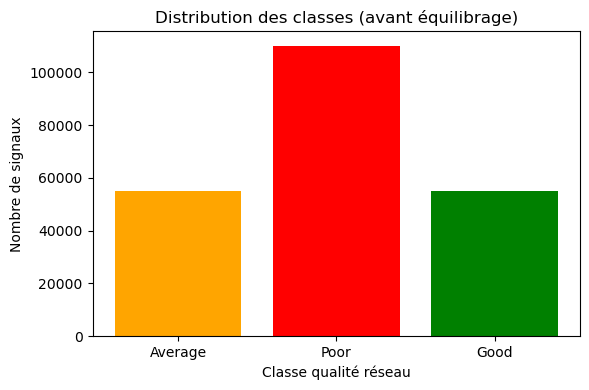

In [4]:
# Distribution des classes avant équilibrage
colors_map = {'Good': 'green', 'Average': 'orange', 'Poor': 'red'}
counter = Counter(y)

plt.figure(figsize=(6, 4))
plt.bar(counter.keys(), counter.values(),
        color=[colors_map[k] for k in counter.keys()])
plt.title("Distribution des classes (avant équilibrage)")
plt.xlabel("Classe qualité réseau")
plt.ylabel("Nombre de signaux")
plt.tight_layout()
plt.show()

SNR disponibles : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


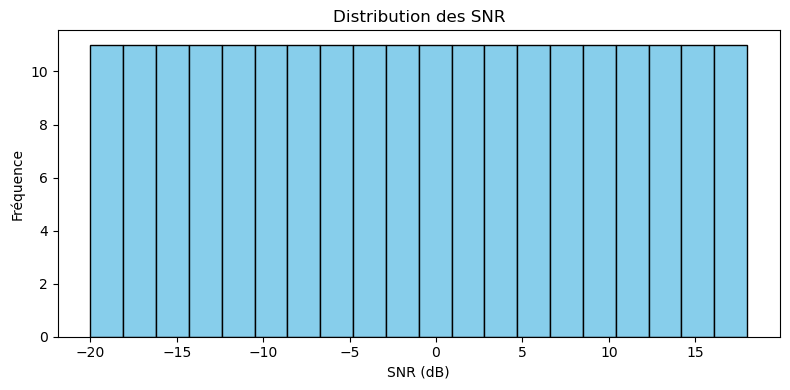

In [5]:
# Distribution des niveaux de SNR dans le dataset
snrs = [key[1] for key in data.keys()]
print("SNR disponibles :", sorted(set(snrs)))

plt.figure(figsize=(8, 4))
plt.hist(snrs, bins=len(set(snrs)), color='skyblue', edgecolor='black')
plt.title("Distribution des SNR")
plt.xlabel("SNR (dB)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

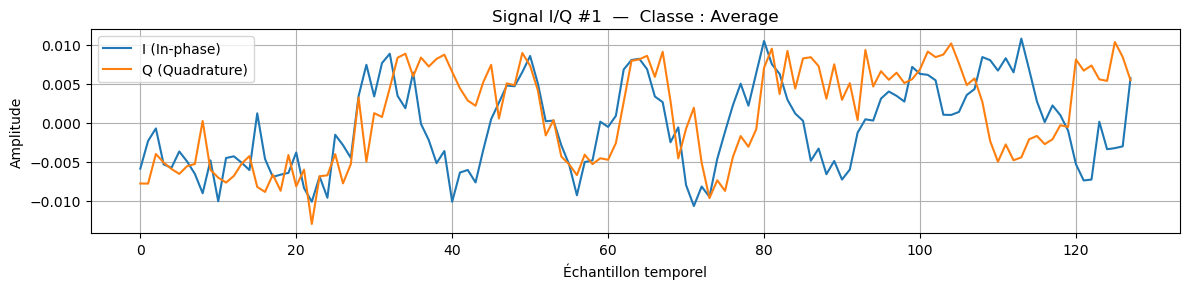

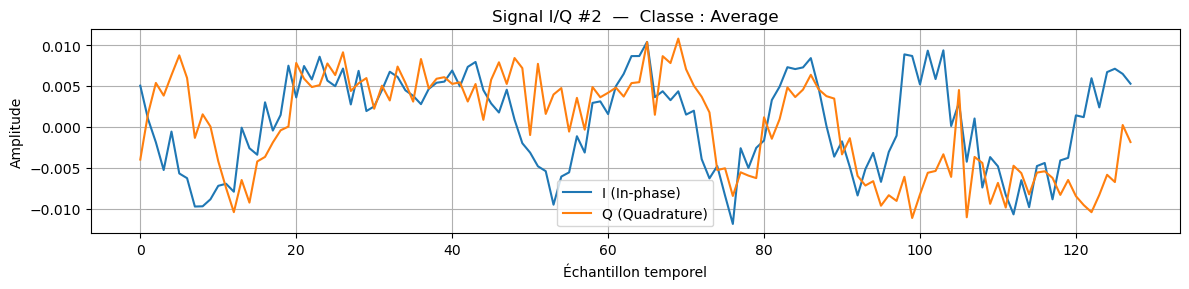

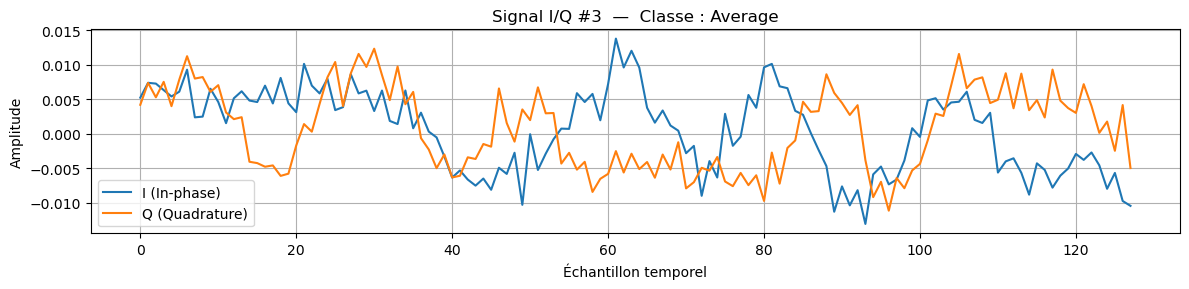

In [6]:
# Visualisation de 3 signaux I/Q
# I = In-phase (partie réelle), Q = Quadrature (partie imaginaire du signal complexe)
for i in range(3):
    plt.figure(figsize=(12, 3))
    plt.plot(X[i][0], label='I (In-phase)')
    plt.plot(X[i][1], label='Q (Quadrature)')
    plt.title(f"Signal I/Q #{i+1}  —  Classe : {y[i]}")
    plt.xlabel("Échantillon temporel")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

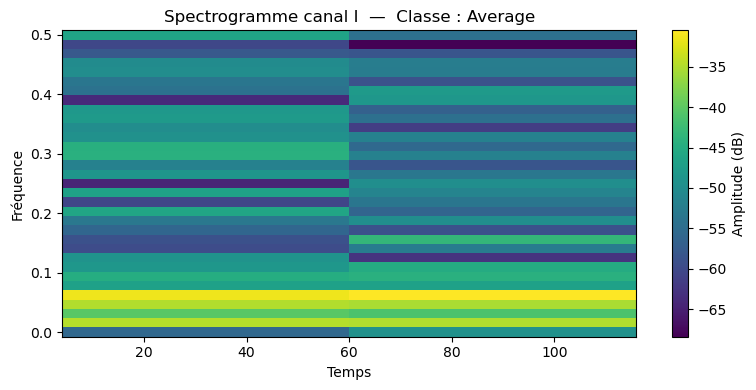

In [7]:
from scipy import signal as sp_signal

# Spectrogramme du canal I du premier signal
# nperseg=64 car chaque signal ne fait que 128 échantillons
# +1e-10 pour éviter log(0)
f_ax, t_ax, Sxx = sp_signal.spectrogram(X[0][0], nperseg=64)

plt.figure(figsize=(8, 4))
plt.pcolormesh(t_ax, f_ax, 10 * np.log10(Sxx + 1e-10))
plt.title(f"Spectrogramme canal I  —  Classe : {y[0]}")
plt.xlabel("Temps")
plt.ylabel("Fréquence")
plt.colorbar(label="Amplitude (dB)")
plt.tight_layout()
plt.show()

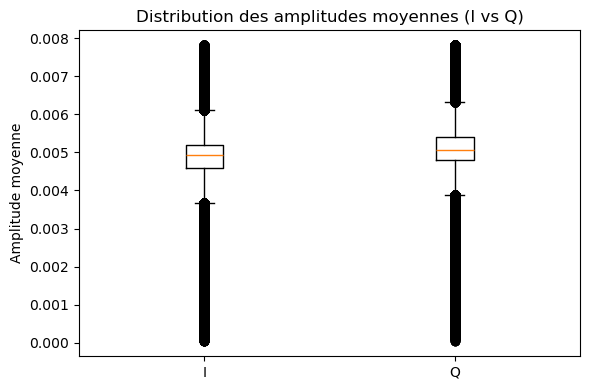

In [8]:
# Boxplot amplitudes I vs Q
# Vérifie que les deux canaux ont une dynamique comparable
I_amps = [np.mean(np.abs(s[0])) for s in X]
Q_amps = [np.mean(np.abs(s[1])) for s in X]

plt.figure(figsize=(6, 4))
plt.boxplot([I_amps, Q_amps], tick_labels=['I', 'Q'])
plt.title("Distribution des amplitudes moyennes (I vs Q)")
plt.ylabel("Amplitude moyenne")
plt.tight_layout()
plt.show()

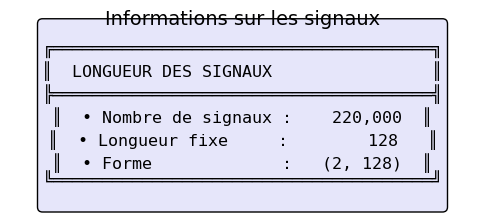

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

info = f"""
╔══════════════════════════════════════╗
║  LONGUEUR DES SIGNAUX                ║
╠══════════════════════════════════════╣
║  • Nombre de signaux : {len(X):>10,}  ║
║  • Longueur fixe     : {X[0].shape[1]:>10}   ║
║  • Forme             : {str(X[0].shape):>10}  ║
╚══════════════════════════════════════╝
"""
ax.text(0.5, 0.5, info, transform=ax.transAxes, fontsize=12,
        verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lavender'))
plt.title("Informations sur les signaux", fontsize=14, pad=10)
plt.show()

Corrélation I/Q : 0.3793


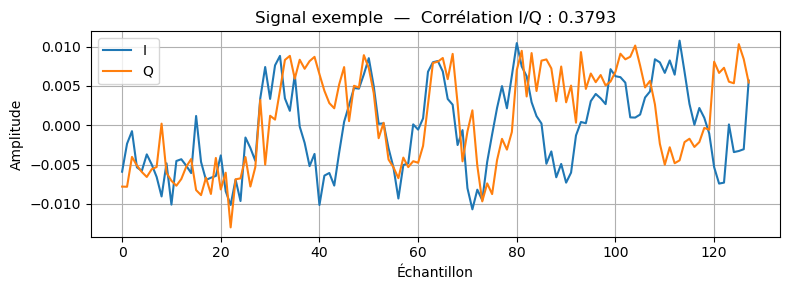

In [9]:
# Corrélation I/Q sur un signal exemple
# I et Q doivent idéalement être peu corrélés (informations complémentaires)
sample = X[0]
corr = np.corrcoef(sample[0], sample[1])[0, 1]
print(f"Corrélation I/Q : {corr:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(sample[0], label='I')
plt.plot(sample[1], label='Q')
plt.title(f"Signal exemple  —  Corrélation I/Q : {corr:.4f}")
plt.xlabel("Échantillon")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

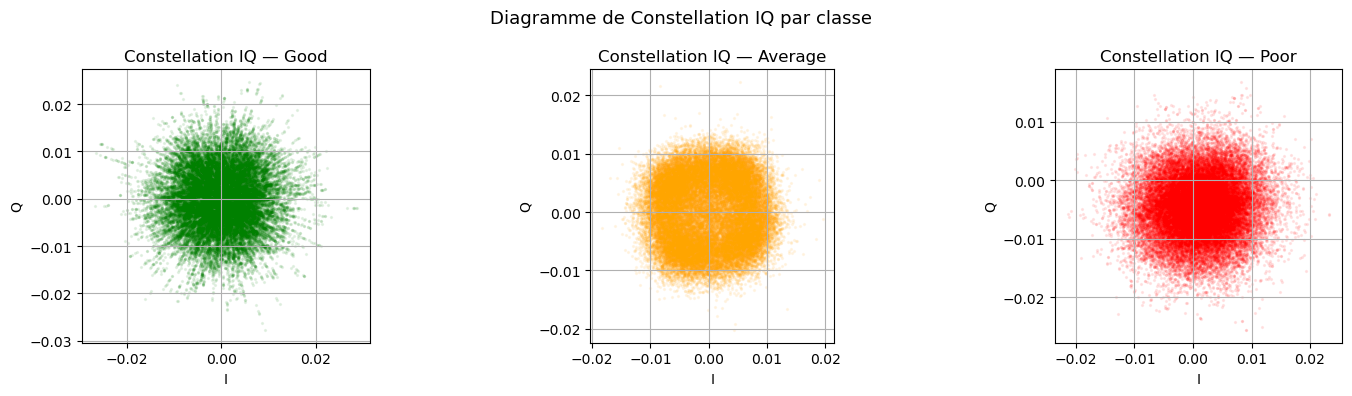

In [10]:
# ============================================================
# DIAGRAMME DE CONSTELLATION I/Q par classe
# ============================================================
# Visualisation standard en communications radio.
# Chaque point = un échantillon (I, Q) d'un signal.
#   Good  → constellation concentrée (SNR fort, peu de bruit)
#   Poor  → points dispersés (SNR faible, bruit dominant)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls in zip(axes, ['Good', 'Average', 'Poor']):
    idx_cls = np.where(y == cls)[0][:300]   # 300 signaux max pour lisibilité
    for idx in idx_cls:
        ax.scatter(X[idx][0], X[idx][1],
                   alpha=0.08, s=2, color=colors_map[cls])
    ax.set_title(f"Constellation IQ — {cls}")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.grid(True)
    ax.set_aspect('equal')

plt.suptitle("Diagramme de Constellation IQ par classe", fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Équilibrage des Classes (Under-sampling)

Le dataset est déséquilibré : il y a plus de niveaux SNR négatifs (Poor) que positifs.
On réduit chaque classe à la taille de la **plus petite classe** par tirage aléatoire sans remise.

**Pourquoi under-sampling et non SMOTE ?**
Le dataset est synthétique et volumineux — on a assez d'exemples dans chaque classe.
L'under-sampling est plus simple, plus rapide, et évite de créer de faux exemples.

Taille cible par classe : 55,000
Après équilibrage : Counter({np.str_('Poor'): 55000, np.str_('Good'): 55000, np.str_('Average'): 55000})
X_balanced shape  : (165000, 2, 128)


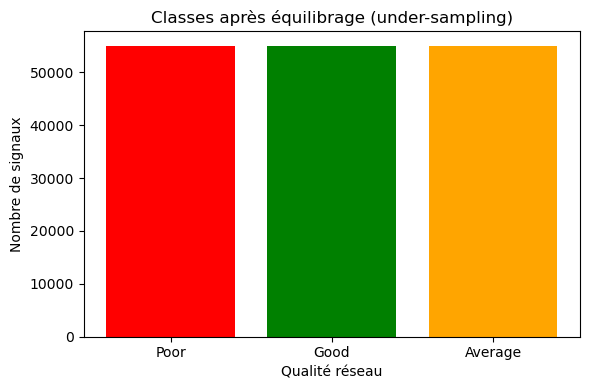

In [11]:
np.random.seed(42)  # reproductibilité

def balance_classes(X, y):
    """Under-sampling : chaque classe est réduite à la taille de la plus petite."""
    classes = np.unique(y)
    idx_by_class = {c: np.where(y == c)[0] for c in classes}
    min_size = min(len(v) for v in idx_by_class.values())
    print(f"Taille cible par classe : {min_size:,}")

    balanced = []
    for c, idx in idx_by_class.items():
        balanced.extend(np.random.choice(idx, min_size, replace=False))

    balanced = np.array(balanced)
    np.random.shuffle(balanced)   # mélanger pour éviter tout biais d'ordre
    return X[balanced], y[balanced]


X_balanced, y_balanced = balance_classes(X, y)

print("Après équilibrage :", Counter(y_balanced))
print("X_balanced shape  :", X_balanced.shape)

# Vérification visuelle
counter_bal = Counter(y_balanced)
plt.figure(figsize=(6, 4))
plt.bar(counter_bal.keys(), counter_bal.values(),
        color=[colors_map[k] for k in counter_bal.keys()])
plt.title("Classes après équilibrage (under-sampling)")
plt.xlabel("Qualité réseau")
plt.ylabel("Nombre de signaux")
plt.tight_layout()
plt.show()

---
## 6. Split Train / Validation / Test

| Ensemble | Proportion | Rôle |
|----------|-----------|------|
| Train    | 70 %      | Mise à jour des poids |
| Validation | 15 %    | Early stopping, suivi de la convergence |
| Test     | 15 %      | Évaluation finale (jamais vu pendant l'entraînement) |

`stratify` garantit que chaque sous-ensemble a la même proportion de classes.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encodage des labels texte → entiers (requis par CrossEntropyLoss)
# LabelEncoder trie alphabétiquement : Average=0, Good=1, Poor=2
le = LabelEncoder()
y_enc = le.fit_transform(y_balanced)
print("Mapping classes :", dict(zip(le.classes_, le.transform(le.classes_))))

# Étape 1 : 85% temporaire / 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced, y_enc, test_size=0.15, random_state=42, stratify=y_enc)

# Étape 2 : 70% train / 15% val (0.176 ≈ 15/85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"\nTrain : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Mapping classes : {np.str_('Average'): np.int64(0), np.str_('Good'): np.int64(1), np.str_('Poor'): np.int64(2)}

Train : (115566, 2, 128)
Val   : (24684, 2, 128)
Test  : (24750, 2, 128)


---
## 7. Préparation PyTorch : Normalisation & DataLoaders

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# -----------------------------------------------
# Dataset PyTorch personnalisé
# -----------------------------------------------
class RadioMLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)   # (N, 2, 128)
        self.y = torch.LongTensor(y)    # entiers pour CrossEntropyLoss
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------------------------
# Normalisation Z-score — UNIQUEMENT sur le train
# On applique ensuite les mêmes mean/std sur val et test
# (sinon : fuite d'information depuis val/test vers le modèle)
# -----------------------------------------------
mean = X_train.mean()
std  = X_train.std()

X_train_n = (X_train - mean) / std
X_val_n   = (X_val   - mean) / std
X_test_n  = (X_test  - mean) / std

# -----------------------------------------------
# DataLoaders
# batch_size=256 : bon compromis vitesse / stabilité du gradient
# shuffle=True sur le train uniquement
# -----------------------------------------------
batch_size   = 256
train_loader = DataLoader(RadioMLDataset(X_train_n, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(RadioMLDataset(X_val_n,   y_val),   batch_size=batch_size)
test_loader  = DataLoader(RadioMLDataset(X_test_n,  y_test),  batch_size=batch_size)

print("DataLoaders prêts.")

DataLoaders prêts.


In [ ]:
#J’ai implémenté un modèle CNN 1D sous PyTorch pour classifier les signaux radio en 3 classes.
#Les données sont organisées avec Dataset et DataLoader.
#Le modèle contient 3 couches convolutionnelles pour extraire les caractéristiques.
#J’utilise CrossEntropyLoss et Adam pour l’optimisation.
#L’entraînement se fait sur 10 epochs avec suivi de la loss et de l’accuracy.
#Finalement, j’évalue le modèle sur un test set indépendant pour mesurer sa performance réelle.

---
## 8. Architecture CNN 1D

| Couche | Sortie | Rôle |
|--------|--------|------|
| Conv1d(2→64) + BN + ReLU + MaxPool | (64, 64) | Extraction features basses fréquences |
| Conv1d(64→128) + BN + ReLU + MaxPool | (128, 32) | Features intermédiaires |
| Conv1d(128→256) + BN + ReLU + AdaptiveAvgPool(8) | (256, 8) | Features hautes fréquences |
| Flatten → Linear(2048→128) → Dropout(0.5) → Linear(128→3) | 3 logits | Classification |

- **BatchNorm** : stabilise l'entraînement, accélère la convergence
- **Dropout(0.2)** après conv : légère régularisation
- **Dropout(0.5)** avant sortie : régularisation forte contre l'overfitting
- **AdaptiveAvgPool1d(8)** : fixe la dimension temporelle à 8 indépendamment de l'entrée

In [14]:
class CNN1D(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            # Bloc 1
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),        # 128 → 64
            nn.Dropout(0.2),

            # Bloc 2
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),        # 64 → 32
            nn.Dropout(0.2),

            # Bloc 3
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),  # → (256, 8) quelle que soit la longueur

            # Tête de classification
            nn.Flatten(),
            nn.Linear(256 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)   # logits pour les 3 classes
        )

    def forward(self, x):
        return self.net(x)


# -----------------------------------------------
# Initialisation
# -----------------------------------------------
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNN1D(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()                          # multi-classe standard
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # lr=0.001 bon point de départ

# ReduceLROnPlateau : divise le lr par 2 si val_loss ne s'améliore pas après 3 epochs
# verbose supprimé (retiré dans PyTorch >= 2.2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Résumé des paramètres
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Dispositif       : {device}")
print(f"Paramètres total : {total_p:,}")
print(f"Entraînables     : {trainable_p:,}")

Dispositif       : cpu
Paramètres total : 387,267
Entraînables     : 387,267


---
## 9. Fonctions Entraînement & Évaluation

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entraîne sur une epoch, retourne (loss_moy, accuracy)."""
    model.train()   # active Dropout + BatchNorm en mode train
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in tqdm(loader, desc="  Train", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Évalue sans gradient, retourne (loss_moy, accuracy)."""
    model.eval()    # désactive Dropout, fixe les stats BatchNorm
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="  Eval ", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            out  = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * xb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += yb.size(0)

    return total_loss / total, correct / total

---
## 10. Entraînement avec Early Stopping

**Early Stopping** : si la `val_loss` ne s'améliore pas pendant `patience` epochs
consécutives, on arrête et on recharge le meilleur modèle sauvegardé.
Cela évite l'overfitting et économise du temps de calcul.

In [17]:
NUM_EPOCHS     = 10   # suffisant pour RadioML (convergence rapide sur dataset synthétique)
PATIENCE       = 3    # early stopping si pas d'amélioration pendant 3 epochs

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss   = float('inf')
epochs_no_impr  = 0

print(f"Entraînement  —  max {NUM_EPOCHS} epochs  |  patience={PATIENCE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

    # Ajuster le LR si val_loss stagne (ReduceLROnPlateau)
    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(tr_loss);  val_losses.append(vl_loss)
    train_accs.append(tr_acc);     val_accs.append(vl_acc)

    print(f"  Train → Loss: {tr_loss:.4f} | Acc: {tr_acc*100:.2f}%")
    print(f"  Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc*100:.2f}%  |  LR: {current_lr:.6f}")

    # Sauvegarde du meilleur modèle + early stopping
    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        epochs_no_impr = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✅ Meilleur modèle sauvegardé (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_impr += 1
        print(f"  ⏳ Pas d'amélioration ({epochs_no_impr}/{PATIENCE})")
        if epochs_no_impr >= PATIENCE:
            print(f"\n🛑 Early Stopping à l'epoch {epoch}")
            break

print("\nEntraînement terminé.")

Entraînement  —  max 10 epochs  |  patience=3

Epoch 1/10


  Train → Loss: 0.5312 | Acc: 79.17%
  Val   → Loss: 0.4452 | Acc: 84.62%  |  LR: 0.001000
  ✅ Meilleur modèle sauvegardé (val_loss=0.4452)
Epoch 2/10


  Train → Loss: 0.4223 | Acc: 84.31%
  Val   → Loss: 0.4127 | Acc: 85.80%  |  LR: 0.001000
  ✅ Meilleur modèle sauvegardé (val_loss=0.4127)
Epoch 3/10


  Train → Loss: 0.3946 | Acc: 85.40%
  Val   → Loss: 0.3625 | Acc: 86.57%  |  LR: 0.001000
  ✅ Meilleur modèle sauvegardé (val_loss=0.3625)
Epoch 4/10


  Train → Loss: 0.3765 | Acc: 86.27%
  Val   → Loss: 0.3305 | Acc: 88.52%  |  LR: 0.001000
  ✅ Meilleur modèle sauvegardé (val_loss=0.3305)
Epoch 5/10


...

  Train → Loss: 0.3547 | Acc: 87.11%
  Val   → Loss: 0.3291 | Acc: 88.41%  |  LR: 0.001000
  ✅ Meilleur modèle sauvegardé (val_loss=0.3291)
Epoch 7/10


  Train → Loss: 0.3495 | Acc: 87.48%
  Val   → Loss: 0.3293 | Acc: 88.52%  |  LR: 0.001000
  ⏳ Pas d'amélioration (1/3)
Epoch 8/10


  Train → Loss: 0.3453 | Acc: 87.61%
  Val   → Loss: 0.3262 | Acc: 88.15%  |  LR: 0.001000
  ✅ Meilleur modèle sauvegardé (val_loss=0.3262)
Epoch 9/10


  Train → Loss: 0.3381 | Acc: 87.96%
  Val   → Loss: 0.3359 | Acc: 88.18%  |  LR: 0.001000
  ⏳ Pas d'amélioration (1/3)
Epoch 10/10


  Train → Loss: 0.3316 | Acc: 88.18%
  Val   → Loss: 0.3805 | Acc: 86.04%  |  LR: 0.001000
  ⏳ Pas d'amélioration (2/3)

Entraînement terminé.


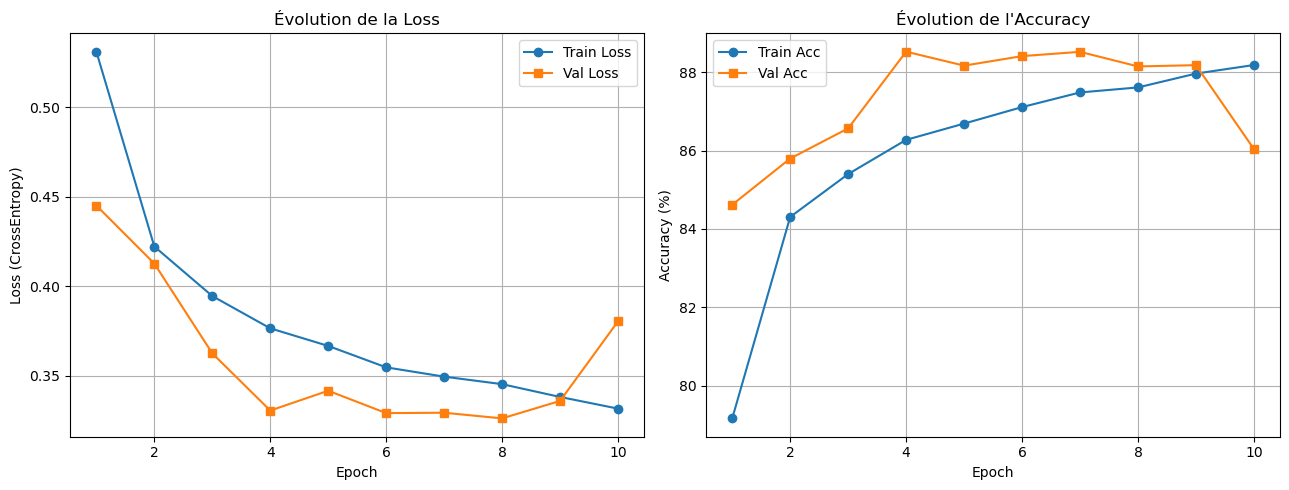

In [18]:
# Courbes d'apprentissage
# - Train loss doit descendre régulièrement
# - Val loss doit suivre la train loss (si écart croissant → overfitting)
erange = range(1, len(train_losses) + 1)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(erange, train_losses, label='Train Loss', marker='o')
plt.plot(erange, val_losses,   label='Val Loss',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropy)')
plt.title('Évolution de la Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(erange, [a * 100 for a in train_accs], label='Train Acc', marker='o')
plt.plot(erange, [a * 100 for a in val_accs],   label='Val Acc',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Évolution de l\'Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## 11. Évaluation Finale sur le Test Set

On recharge le **meilleur modèle** (val_loss minimale) et on l'évalue
sur le test set qui n'a **jamais été vu** pendant l'entraînement.

Test Loss : 0.3332  |  Test Accuracy : 87.77%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Average       0.90      0.83      0.86      8250
        Good       0.94      0.84      0.89      8250
        Poor       0.81      0.97      0.88      8250

    accuracy                           0.88     24750
   macro avg       0.88      0.88      0.88     24750
weighted avg       0.88      0.88      0.88     24750



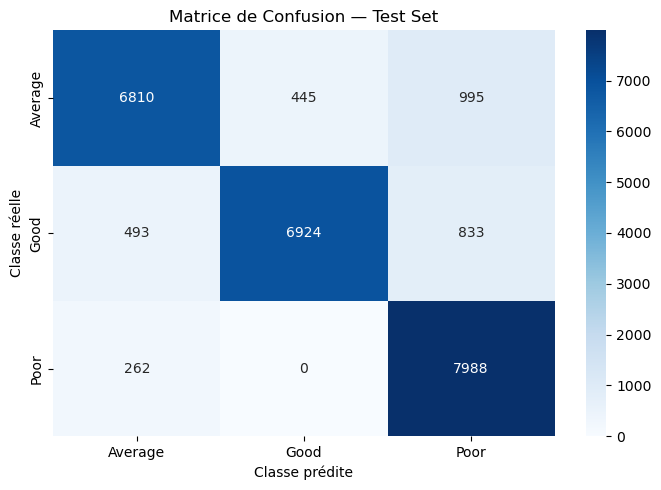

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Noms des classes dans l'ordre du LabelEncoder (alphabétique)
# Average=0, Good=1, Poor=2
class_names = list(le.classes_)

# Recharger le meilleur modèle
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Prédictions sur le test set
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

# --- Accuracy globale ---
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss : {test_loss:.4f}  |  Test Accuracy : {test_acc*100:.2f}%\n")

# --- Classification Report ---
# Précision : parmi les prédits 'Good', combien sont vrais 'Good' ?
# Recall    : parmi les vrais 'Good', combien sont bien détectés ?
# F1-score  : moyenne harmonique Précision/Recall
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_true, all_preds, target_names=class_names))

# --- Matrice de Confusion ---
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.title('Matrice de Confusion — Test Set')
plt.tight_layout()
plt.show()

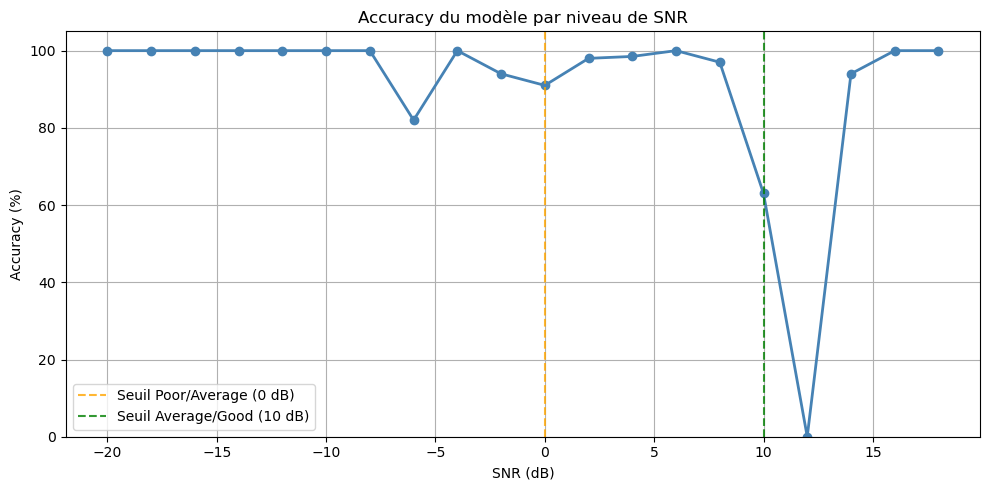

Observation : à fort SNR (≥10 dB) le signal est propre → classification facile.
À faible SNR (<0 dB) le bruit domine → le modèle a plus de mal à distinguer les classes.


In [20]:
# ============================================================
# ACCURACY PAR NIVEAU DE SNR
# ============================================================
# Courbe fondamentale en traitement de signal :
# montre que le modèle performe mieux quand le SNR est élevé
# (signal propre → patterns clairs) et moins bien à faible SNR
# (bruit dominant → patterns masqués). Comportement attendu.
# ============================================================

snr_values  = sorted(set(key[1] for key in data.keys()))
acc_per_snr = {}

model.eval()
with torch.no_grad():
    for snr_val in snr_values:
        sigs, labs = [], []
        for (mod, s), signals in data.items():
            if s == snr_val:
                for sig in signals:
                    sigs.append(sig)
                    labs.append('Good' if snr_val >= 10 else
                                'Average' if snr_val >= 0 else 'Poor')

        # Limite à 200 signaux par SNR pour la rapidité
        X_s = np.array(sigs[:200])
        y_s = torch.LongTensor(le.transform(labs[:200]))

        X_s_norm = torch.FloatTensor((X_s - mean) / std).to(device)
        preds_s  = model(X_s_norm).argmax(1).cpu()
        acc_per_snr[snr_val] = (preds_s == y_s).float().mean().item() * 100

plt.figure(figsize=(10, 5))
plt.plot(list(acc_per_snr.keys()), list(acc_per_snr.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=0,  color='orange', linestyle='--', alpha=0.8, label='Seuil Poor/Average (0 dB)')
plt.axvline(x=10, color='green',  linestyle='--', alpha=0.8, label='Seuil Average/Good (10 dB)')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy du modèle par niveau de SNR")
plt.legend()
plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("Observation : à fort SNR (≥10 dB) le signal est propre → classification facile.")
print("À faible SNR (<0 dB) le bruit domine → le modèle a plus de mal à distinguer les classes.")

---
## 12. Conclusion

### Bilan du projet
| Étape | Statut |
|-------|--------|
| Chargement & exploration RadioML 2016.10a | ✅ |
| Labellisation SNR → Good / Average / Poor | ✅ |
| Vérification qualité (NaN, inf, min/max) | ✅ |
| Visualisations (IQ, spectrogramme, constellation, boxplot) | ✅ |
| Équilibrage par under-sampling | ✅ |
| Split stratifié 70/15/15 | ✅ |
| CNN 1D avec BatchNorm, Dropout, AdaptiveAvgPool | ✅ |
| Entraînement : Early Stopping + ReduceLROnPlateau | ✅ |
| Évaluation : Matrice de confusion + F1-score + Accuracy vs SNR | ✅ |

### Limites & Pistes d'amélioration
- Dataset **synthétique** → performances peuvent baisser sur signaux réels capturés en environnement bruité
- Explorer **LSTM** ou **Transformer** pour capturer des dépendances temporelles longues
- Tester **SMOTE** comme alternative à l'under-sampling
- Déploiement via **Streamlit** pour une démo interactive en temps réel